In [1]:
import tensorflow as tf
print("GPU:",tf.config.list_physical_devices('GPU'))

GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
from google.colab import files
uploded=files.upload()

Saving archive.zip to archive.zip


In [3]:
import zipfile
zip_path="archive.zip"
with zipfile.ZipFile(zip_path,"r") as zip_ref:
    zip_ref.extractall("flood_data")
!ls flood_data

Image  Mask  metadata.csv


In [4]:
import os, cv2, numpy as np, pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tensorflow.keras import layers, Model
import tensorflow.keras.backend as K

In [5]:
data_dir="flood_data"
df=pd.read_csv(os.path.join(data_dir,"/content/metadata (1).csv"))

IMG_DIR=os.path.join(data_dir,"Image")
MASK_DIR=os.path.join(data_dir,"Mask")
IMG_SIZE=256


In [7]:
def load_data(df):
    images, masks = [], []
    for _, row in df.iterrows():
        img = cv2.imread(os.path.join(IMG_DIR, row['Image']))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

        mask = cv2.imread(os.path.join(MASK_DIR, row['Mask']), cv2.IMREAD_GRAYSCALE)
        mask = cv2.resize(mask, (IMG_SIZE, IMG_SIZE))
        mask = (mask > 127).astype(np.float32)
        mask = np.expand_dims(mask, axis=-1)

        images.append(img)
        masks.append(mask)
    return np.array(images, dtype=np.float32), np.array(masks, dtype=np.float32)

X, Y = load_data(df)
X=X/255.0
print("Images shape:", X.shape, "| Masks shape:", Y.shape)

Images shape: (290, 256, 256, 3) | Masks shape: (290, 256, 256, 1)


In [8]:
X_train, X_val, Y_train, Y_val = train_test_split(X, Y, test_size=0.15, random_state=42)
print("Train:", X_train.shape, "| Validation:", X_val.shape)

Train: (246, 256, 256, 3) | Validation: (44, 256, 256, 3)


In [9]:
def dice_coef(y_true, y_pred, smooth=1):
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (K.sum(y_true_f) + K.sum(y_pred_f) + smooth)

def dice_loss(y_true, y_pred):
    return 1 - dice_coef(y_true, y_pred)

In [16]:
def conv_block(x, filters):
    x = layers.Conv2D(filters, 3, padding='same', activation='relu')(x)
    x = layers.Conv2D(filters, 3, padding='same', activation='relu')(x)
    return x

def build_unet(input_shape=(256,256,3)):
    inputs = layers.Input(input_shape)


    c1 = conv_block(inputs, 32); p1 = layers.MaxPooling2D()(c1)
    c2 = conv_block(p1, 64);     p2 = layers.MaxPooling2D()(c2)
    c3 = conv_block(p2, 128);    p3 = layers.MaxPooling2D()(c3)
    c4 = conv_block(p3, 256);    p4 = layers.MaxPooling2D()(c4)

    bn = conv_block(p4, 512)


    u4 = layers.Conv2DTranspose(256, 2, strides=2, padding='same')(bn)
    u4 = layers.concatenate([u4, c4]); c5 = conv_block(u4, 256)

    u3 = layers.Conv2DTranspose(128, 2, strides=2, padding='same')(c5)
    u3 = layers.concatenate([u3, c3]); c6 = conv_block(u3, 128)

    u2 = layers.Conv2DTranspose(64, 2, strides=2, padding='same')(c6)
    u2 = layers.concatenate([u2, c2]); c7 = conv_block(u2, 64)

    u1 = layers.Conv2DTranspose(32, 2, strides=2, padding='same')(c7)
    u1 = layers.concatenate([u1, c1]); c8 = conv_block(u1, 32)

    outputs = layers.Conv2D(1, 1, activation='sigmoid')(c8)
    return Model(inputs, outputs)

model = build_unet()
def bce_dice_loss(y_true, y_pred):
    bce = tf.keras.losses.binary_crossentropy(y_true, y_pred)
    return bce + dice_loss(y_true, y_pred)

model.compile(
    optimizer='adam',
    loss=bce_dice_loss,
    metrics=[dice_coef]
)
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_19 (Conv2D)  │ (None, 256, 256,  │        896 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_20 (Conv2D)  │ (None, 256, 256,  │      9,248 │ conv2d_19[0][0]   │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_4     │ (None, 128, 128,  │          0 │ conv2d_20[0][0]   │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_21 (Conv2D)  │ (None, 128, 128,  │     18,496 │ max_pooling2d_4[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_22 (Conv2D)  │ (None, 128, 128,  │     36,928 │ conv2d_21[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_5     │ (None, 64, 64,    │          0 │ conv2d_22[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_23 (Conv2D)  │ (None, 64, 64,    │     73,856 │ max_pooling2d_5[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_24 (Conv2D)  │ (None, 64, 64,    │    147,584 │ conv2d_23[0][0]   │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_6     │ (None, 32, 32,    │          0 │ conv2d_24[0][0]   │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_25 (Conv2D)  │ (None, 32, 32,    │    295,168 │ max_pooling2d_6[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_26 (Conv2D)  │ (None, 32, 32,    │    590,080 │ conv2d_25[0][0]   │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_7     │ (None, 16, 16,    │          0 │ conv2d_26[0][0]   │
│ (MaxPooling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_27 (Conv2D)  │ (None, 16, 16,    │  1,180,160 │ max_pooling2d_7[… │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_28 (Conv2D)  │ (None, 16, 16,    │  2,359,808 │ conv2d_27[0][0]   │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_4  │ (None, 32, 32,    │    524,544 │ conv2d_28[0][0]   │
│ (Conv2DTranspose)   │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_4       │ (None, 32, 32,    │          0 │ conv2d_transpose

 Total params: 7,760,097 (29.60 MB)

 Trainable params: 7,760,097 (29.60 MB)

 Non-trainable params: 0 (0.00 B)

In [17]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

data_gen_args = dict(rotation_range=15, horizontal_flip=True,
                      width_shift_range=0.1, height_shift_range=0.1)

img_gen = ImageDataGenerator(**data_gen_args)
mask_gen = ImageDataGenerator(**data_gen_args)

seed = 1
img_gen.fit(X_train, augment=True, seed=seed)
mask_gen.fit(Y_train, augment=True, seed=seed)

batch_size = 8
train_img_flow = img_gen.flow(X_train, batch_size=batch_size, seed=seed)
train_mask_flow = mask_gen.flow(Y_train, batch_size=batch_size, seed=seed)
def train_generator():
    while True:
        imgs = next(train_img_flow)
        masks = next(train_mask_flow)
        yield imgs, masks

In [18]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=8,
    restore_best_weights=True
)

In [21]:
history = model.fit(
    X_train,
    Y_train,
    validation_data=(X_val, Y_val),
    batch_size=8,
    epochs=60,
    callbacks=[early_stop]
)

Epoch 1/60
31/31 ━━━━━━━━━━━━━━━━━━━━ 5s 173ms/step - dice_coef: 0.7816 - loss: 0.5554 - val_dice_coef: 0.7428 - val_loss: 0.6347
Epoch 2/60
31/31 ━━━━━━━━━━━━━━━━━━━━ 5s 173ms/step - dice_coef: 0.7844 - loss: 0.5442 - val_dice_coef: 0.7933 - val_loss: 0.5540
Epoch 3/60
31/31 ━━━━━━━━━━━━━━━━━━━━ 5s 175ms/step - dice_coef: 0.7927 - loss: 0.5328 - val_dice_coef: 0.7885 - val_loss: 0.6398
Epoch 4/60
31/31 ━━━━━━━━━━━━━━━━━━━━ 5s 175ms/step - dice_coef: 0.7949 - loss: 0.5265 - val_dice_coef: 0.7963 - val_loss: 0.5790
Epoch 5/60
31/31 ━━━━━━━━━━━━━━━━━━━━ 6s 178ms/step - dice_coef: 0.7883 - loss: 0.5427 - val_dice_coef: 0.7815 - val_loss: 0.5780
Epoch 6/60
31/31 ━━━━━━━━━━━━━━━━━━━━ 6s 181ms/step - dice_coef: 0.7939 - loss: 0.5217 - val_dice_coef: 0.7939 - val_loss: 0.5397
Epoch 7/60
31/31 ━━━━━━━━━━━━━━━━━━━━ 6s 180ms/step - dice_coef: 0.8039 - loss: 0.4955 - val_dice_coef: 0.8070 - val_loss: 0.5440
Epoch 8/60
31/31 ━━━━━━━━━━━━━━━━━━━━ 6s 180ms/step - dice_coef: 0.7989 - loss: 0.5236 - v

In [22]:
val_loss, val_dice = model.evaluate(X_val, Y_val)
print(f"Validation Dice Coefficient: {val_dice:.4f}")

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - dice_coef: 0.8393 - loss: 0.4275
Validation Dice Coefficient: 0.8393


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 889ms/step


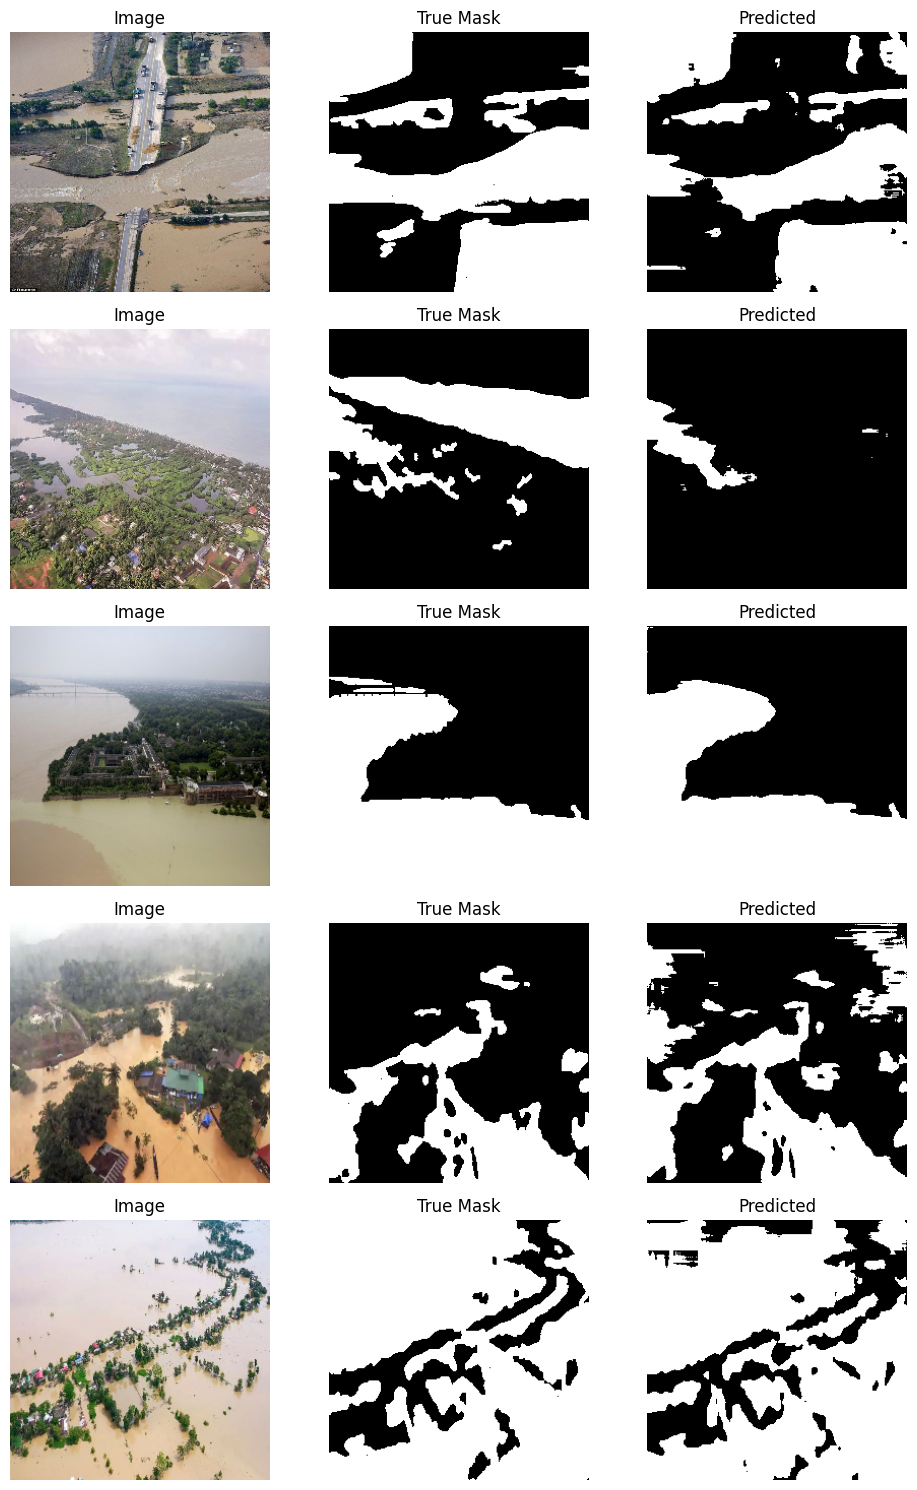

In [23]:
preds = model.predict(X_val[:5])
fig, axes = plt.subplots(5, 3, figsize=(10, 15))
for i in range(5):
    axes[i,0].imshow(X_val[i]); axes[i,0].set_title("Image"); axes[i,0].axis('off')
    axes[i,1].imshow(Y_val[i].squeeze(), cmap='gray'); axes[i,1].set_title("True Mask"); axes[i,1].axis('off')
    axes[i,2].imshow(preds[i].squeeze() > 0.5, cmap='gray'); axes[i,2].set_title("Predicted"); axes[i,2].axis('off')
plt.tight_layout()
plt.show()

In [24]:
model.save("flood_segmentation_unet.h5")
print("Model saved!")

Model saved!


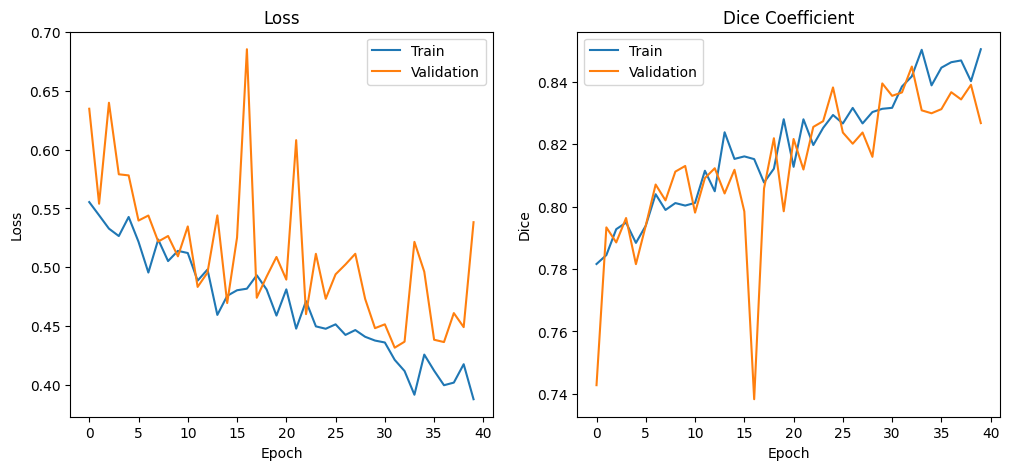

In [28]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train','Validation'])

plt.subplot(1,2,2)
plt.plot(history.history['dice_coef'])
plt.plot(history.history['val_dice_coef'])
plt.title('Dice Coefficient')
plt.xlabel('Epoch')
plt.ylabel('Dice')
plt.legend(['Train','Validation'])

plt.savefig("training_curves.png")
plt.show()
fig.savefig("predictions.png")

In [27]:
fig.savefig("predictions.png")